In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-editorial.fBhWhc/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-editorial.fBhWhc/venv", "python": "3.12.14", "torch_cuda_build": null}


# Can ignored prompt positions still learn?

Chapter 9 · Day 12

Follow the answer loss into shared decoder parameters. Contrast zero direct logit gradient with nonzero graph paths through prompt context.

Use the cycle: prediction → inspect mechanism → change one choice → interpret limits. Runnable reference answers follow each question. All computations use CPU; no model download or server is started.

In [2]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/dongxi_llms").is_dir())
sys.path.insert(0, str(root / "src"))
import math, copy, json
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "font.size": 11})
from dongxi_llms import evaluation_lab as ev
from dongxi_llms import instruction_data_lab as data
from dongxi_llms import sft_lab as sft
def show_flow(labels, focus):
    fig, ax = plt.subplots(figsize=(11, 1.9))
    for i, label in enumerate(labels):
        ax.text(i, .5, label, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=.45", fc="#dce9f5" if i == focus else "#f6f6f6", ec="#666"))
        if i: ax.annotate("", (i-.25,.5), (i-.75,.5), arrowprops=dict(arrowstyle="->",color="#555"))
    ax.set_xlim(-.6,len(labels)-.4); ax.set_ylim(0,1); ax.axis("off")
    ax.set_title("Schematic process: highlighted component is this lesson's focus")
    plt.show()


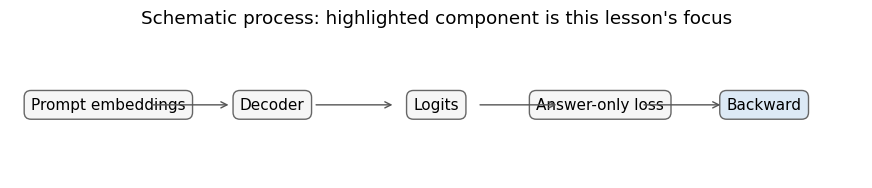

In [3]:
show_flow(["Prompt embeddings","Decoder","Logits","Answer-only loss","Backward"], 4)

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 sft objective and gradient paths: reference plot 01](../figures/chapter-09/day-12-01_sft_objective_and_gradient_paths-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

### Prediction

## Predict 1

Predict where direct logit gradients are zero when only assistant body and END labels are supervised.

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


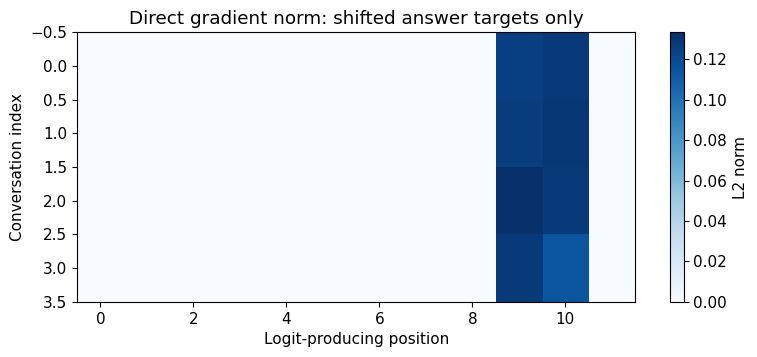

In [4]:
batch=data.collate(data.instruction_fixture())
torch.manual_seed(1212)
logits=torch.randn(4,batch["input_ids"].shape[1],22,requires_grad=True)
summed,count=sft.token_loss_sum(logits,batch["labels"]); (summed/count).backward()
direct=logits.grad.norm(dim=-1).numpy()
fig,ax=plt.subplots(figsize=(9,3.5))
image=ax.imshow(direct,cmap="Blues",aspect="auto")
ax.set(xlabel="Logit-producing position",ylabel="Conversation index",title="Direct gradient norm: shifted answer targets only")
fig.colorbar(image,ax=ax,label="L2 norm"); plt.show()
ignored=batch["labels"][:,1:]==-100
assert torch.all(logits.grad[:,:-1][ignored]==0)

### Reference explanation

### Reference answer and mechanism

Ignored target positions have zero direct logit gradients. Their earlier hidden states may still affect later supervised positions through the causal graph.


**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 sft objective and gradient paths: reference plot 02](../figures/chapter-09/day-12-01_sft_objective_and_gradient_paths-02.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

### Prediction

## Predict 2

Do the attention projections and user-token embedding receive training signal in this tiny full-SFT model?

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


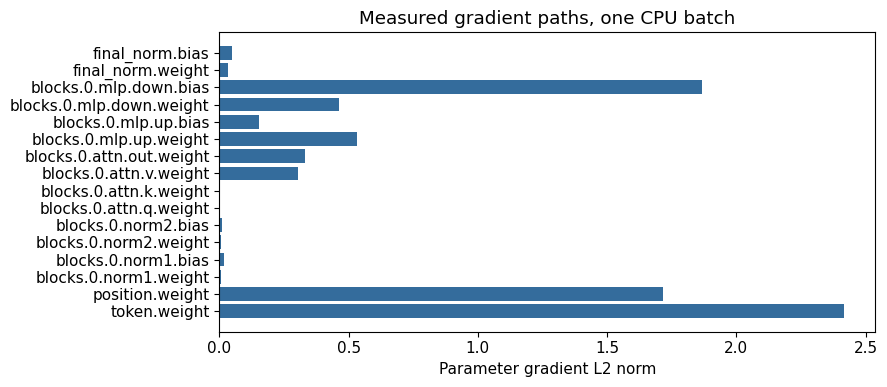

In [5]:
model=sft.make_model(); summed,count=sft.token_loss_sum(model(batch["input_ids"]),batch["labels"])
(summed/count).backward()
norms={name:float(p.grad.norm()) for name,p in model.named_parameters() if p.grad is not None}
fig,ax=plt.subplots(figsize=(9,4))
ax.barh(list(norms),list(norms.values()),color="#346c9c")
ax.set(xlabel="Parameter gradient L2 norm",title="Measured gradient paths, one CPU batch")
plt.tight_layout(); plt.show()
assert float(model.token.weight.grad[data.SPECIAL["user"]].norm())>0

### Reference explanation

### Reference answer and mechanism

They can. The loss propagates through final states, attention content/routing and visible prompt embeddings. Parameter norms below are measured for this fixture.


**Saved reference preview — rerun the preceding plot cell for current inputs.**

![01 sft objective and gradient paths: reference plot 03](../figures/chapter-09/day-12-01_sft_objective_and_gradient_paths-03.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

### Prediction

## Predict 3

Why can an unused input embedding row still receive a gradient when the output head is tied?

Pause and explain your reasoning before running the next cell.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [6]:
unused=data.VOCAB["kind"]
assert unused not in batch["input_ids"]
print("Unused-as-input row gradient norm:",float(model.token.weight.grad[unused].norm()))
assert float(model.token.weight.grad[unused].norm())>0

Unused-as-input row gradient norm: 0.1462780088186264


### Reference explanation

### Reference answer and mechanism

The same table participates in the output projection. Every vocabulary candidate enters softmax, so output gradients can update a row never looked up as an input.

## Reading the evidence

The figures are regenerated from the current lesson tensors or declared fixture. Axes and counts define the comparison. Change one control, rerun the relevant cell, and explain what changed in the mechanism. Separate a verified implementation property from a claim about a real language model.

Return to the corresponding chapter and worked solution for the complete argument.
